💡 **Environment:** `clamp-analyses`

# Description

**Per-disease performance summary + disease-level cluster bootstrap.** Consumes `per_disease_metrics.csv` (from `00_per_disease_metrics.ipynb`).

Computing AUROC/AUPRC **within each disease** removes disease-level popularity by construction (the disease node is fixed). Here we (1) summarize the distribution of per-disease metrics across diseases per method, (2) test pairwise **macro-mean** differences with a **disease-level cluster bootstrap**, and (3) plot.

**Why a *disease*-level bootstrap.** The existing `../signif_test` bootstrap resamples *pairs*. Once the disease node is fixed, the independent unit is the **disease**, not the pair (within-disease pairs share a disease and overlapping drugs). So we resample **diseases** with replacement and recompute each method's macro-mean on the *same* resampled disease set — paired across methods, so differences are taken by subtraction (cancels cross-method correlation), exactly as in `signif_test`. Per-disease AUROC values are precomputed (NB00) and never change; bootstrap = pure array indexing.

**Macro-mean weights diseases EQUALLY** (one vote per disease) — the estimand that removes disease popularity. n-weighting would re-pool it.

**Headline = the 33 AUROC-eligible diseases; robustness = the strict 17 (≥3 pos & ≥3 neg).** The macro-mean ordering is threshold-sensitive (see findings), so we run the bootstrap on **both** sets.

**AUPRC headline = log2 fold-enrichment over the per-disease prior** (`auprc_log2_enrich`), not raw AUPRC (base rates span ~0.36–0.95, so raw AUPRC mostly reads prevalence). Reported as macro-mean **and median** (the log ratio can produce large negative outliers).

Helpers `boot_ci`/`boot_pvalue_two_sided`/`bh_correct` are **copied verbatim from `../signif_test/01_paired_bootstrap_test.ipynb`** (not imported) to keep the directory isolated.

# Modules loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyprojroot import here

# Settings

In [3]:
SEED = 42
N_BOOT = 10000

# Same fixed order / sign convention as ../signif_test: for a comparison (A, B)
# in METHOD_ORDER, diff = B - A. gene_based first -> gene-vs-module rows read
# 'module - gene' (> 0 means the module model beats the single-gene baseline).
METHOD_ORDER = [
    'gene_based',
    'module_based_archs4',
    'module_based_gtex',
    'module_based_recount2',
]
COMPARISONS = list(itertools.combinations(METHOD_ORDER, 2))  # 6 pairwise

# Metric column in per_disease_metrics.csv -> display name. AUPRC headline is the
# log2 fold-enrichment over the per-disease prior, not raw AUPRC.
METRICS = {
    'AUROC': 'auroc',
    'AUPRC_log2_enrich': 'auprc_log2_enrich',
}

# Two eligibility sets, both reported. 'all' = AUROC-defined (>=1 pos & >=1 neg);
# 'strict' = >=3 pos & >=3 neg (well-powered, less noisy per-disease estimates).
ELIGIBILITY = {
    'all': 'eligible',
    'strict': 'eligible_strict',
}

# Plot labels/colors (internal-name -> NB11 palette).
METHOD_LABEL = {
    'gene_based': 'gene',
    'module_based_archs4': 'ARCHS4',
    'module_based_gtex': 'GTEx',
    'module_based_recount2': 'recount2',
}
METHOD_COLOR = {
    'gene_based': '#444444',
    'module_based_archs4': '#1f77b4',
    'module_based_gtex': '#2ca02c',
    'module_based_recount2': '#d62728',
}

INPUT_DIR = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/per_disease_test')
OUTPUT_DIR = INPUT_DIR
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
display(OUTPUT_DIR)

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/per_disease_test')

# Load per-disease metrics

In [4]:
per_disease = pd.read_csv(INPUT_DIR / 'per_disease_metrics.csv')
per_disease['method'] = pd.Categorical(
    per_disease['method'], categories=METHOD_ORDER, ordered=True)
per_disease = per_disease.sort_values(['method', 'trait']).reset_index(drop=True)
display(per_disease.shape)
display(per_disease.head())

# Eligibility is a property of the disease only -> same count across methods.
n_all = int(per_disease.loc[per_disease['method'] == METHOD_ORDER[0], 'eligible'].sum())
n_strict = int(per_disease.loc[per_disease['method'] == METHOD_ORDER[0], 'eligible_strict'].sum())
display(f'AUROC-eligible diseases: all={n_all}, strict={n_strict}')

(228, 11)

,method,trait,n_pos,n_neg,n_total,base_rate,auroc,auprc,auprc_log2_enrich,eligible,eligible_strict
0,gene_based,DOID:0050741,3,0,3,1.000000,NaN,NaN,NaN,False,False
1,gene_based,DOID:10283,16,7,23,0.695652,0.410714,0.717213,0.044035,True,True
2,gene_based,DOID:10534,9,0,9,1.000000,NaN,NaN,NaN,False,False
3,gene_based,DOID:10652,4,7,11,0.363636,0.178571,0.287338,-0.339749,True,True
4,gene_based,DOID:10763,58,27,85,0.682353,0.363346,0.600091,-0.185336,True,True


'AUROC-eligible diseases: all=33, strict=17'

# Per-disease metric matrices (diseases × methods)

For each eligibility set, pivot to a `disease × method` matrix of the precomputed per-disease metric. All entries are finite (every eligible disease has a defined metric), so the cluster bootstrap needs **no single-class skip** (unlike the pair-level bootstrap).

In [5]:
def metric_matrix(metric_col, eligibility_col):
    """disease × method matrix of a precomputed per-disease metric (eligible diseases)."""
    sub = per_disease[per_disease[eligibility_col]]
    mat = sub.pivot_table(index='trait', columns='method', values=metric_col, observed=True)
    mat = mat[METHOD_ORDER]                     # fix column order
    assert mat.notna().all().all(), f'{metric_col} has NaN among {eligibility_col} diseases'
    return mat

matrices = {
    elig: {mname: metric_matrix(mcol, ecol) for mname, mcol in METRICS.items()}
    for elig, ecol in ELIGIBILITY.items()
}
for elig in ELIGIBILITY:
    display(f"{elig}: {matrices[elig]['AUROC'].shape[0]} diseases × "
            f"{matrices[elig]['AUROC'].shape[1]} methods")

'all: 33 diseases × 4 methods'

'strict: 17 diseases × 4 methods'

# Distribution summary per method

In [6]:
# Per (eligibility, method): macro-mean / median / IQR of AUROC, fraction > 0.5
# (with the count at exactly 0.5 reported separately), and macro-mean AND median
# of the log2 AUPRC enrichment.
summary_rows = []
for elig in ELIGIBILITY:
    auroc = matrices[elig]['AUROC']
    enrich = matrices[elig]['AUPRC_log2_enrich']
    n_dis = auroc.shape[0]
    for m in METHOD_ORDER:
        a = auroc[m].values
        e = enrich[m].values
        summary_rows.append({
            'eligibility': elig,
            'n_diseases': n_dis,
            'method': m,
            'macro_mean_auroc': a.mean(),
            'median_auroc': np.median(a),
            'q25_auroc': np.percentile(a, 25),
            'q75_auroc': np.percentile(a, 75),
            'frac_auroc_gt_0.5': float((a > 0.5).mean()),
            'n_auroc_eq_0.5': int((a == 0.5).sum()),
            'macro_mean_log2enrich': e.mean(),
            'median_log2enrich': np.median(e),
        })
summary = pd.DataFrame(summary_rows)
summary['method'] = pd.Categorical(summary['method'], categories=METHOD_ORDER, ordered=True)
summary = summary.sort_values(['eligibility', 'method']).reset_index(drop=True)

out_summary = OUTPUT_DIR / 'per_disease_macro_summary.csv'
summary.to_csv(out_summary, index=False)
display(out_summary)
display(summary.round(4))

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/per_disease_test/per_disease_macro_summary.csv')

,eligibility,n_diseases,method,macro_mean_auroc,median_auroc,q25_auroc,q75_auroc,frac_auroc_gt_0.5,n_auroc_eq_0.5,macro_mean_log2enrich,median_log2enrich
0,all,33,gene_based,0.6576,0.7222,0.5303,0.8333,0.7576,1,0.1850,0.2251
1,all,33,module_based_archs4,0.6356,0.7500,0.4643,0.8333,0.6970,0,0.1928,0.1659
2,all,33,module_based_gtex,0.6401,0.7130,0.4911,0.7949,0.6667,2,0.1641,0.1699
3,all,33,module_based_recount2,0.6220,0.6667,0.4167,0.8750,0.6667,0,0.1627,0.1247
4,strict,17,gene_based,0.5984,0.7222,0.4242,0.7821,0.6471,1,0.1647,0.1499
5,strict,17,module_based_archs4,0.6493,0.6161,0.4766,0.8333,0.7059,0,0.2491,0.1659
6,strict,17,module_based_gtex,0.5652,0.5000,0.4375,0.7692,0.4706,2,0.1455,0.1260
7,strict,17,module_based_recount2,0.5798,0.6562,0.4167,0.7407,0.5882,0,0.1835,0.1247


# Helpers (copied verbatim from `../signif_test/01_paired_bootstrap_test.ipynb`)

In [7]:
def boot_ci(arr, lo=2.5, hi=97.5):
    return np.percentile(arr, lo), np.percentile(arr, hi)


def boot_pvalue_two_sided(diffs):
    """Two-sided bootstrap p-value for H0: diff == 0.

    Uses the (count + 1) / (N + 1) convention (Davison & Hinkley 1997) so the
    p-value is never exactly 0 -- it is floored at 2 / (N + 1).
    """
    n = len(diffs)
    p_le = ((diffs <= 0).sum() + 1) / (n + 1)
    p_ge = ((diffs >= 0).sum() + 1) / (n + 1)
    return min(2.0 * min(p_le, p_ge), 1.0)


def bh_correct(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = ranked * m / (np.arange(m) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.minimum(adj, 1.0)
    return out

# Disease-level cluster bootstrap

For each eligibility set and metric: resample **diseases** with replacement; recompute every method's macro-mean on the *same* resampled disease set (paired); the 6 pairwise differences are `macro_b − macro_a`. Reuse the same disease resample for both metrics within a set (the metrics are separate families, but a shared resample is natural and keeps within-set comparisons aligned). Across eligibility sets the disease universe differs, so they are bootstrapped separately on the same RNG stream (deterministic, `seed=42`).

In [8]:
np.random.seed(SEED)

# boot_macro[elig][metric] -> array (N_BOOT, n_methods) of resampled macro-means.
boot_macro = {elig: {mname: None for mname in METRICS} for elig in ELIGIBILITY}
observed_macro = {elig: {mname: None for mname in METRICS} for elig in ELIGIBILITY}

for elig in ELIGIBILITY:
    # Pre-extract aligned numpy matrices (diseases × methods), columns = METHOD_ORDER.
    mats = {mname: matrices[elig][mname].values for mname in METRICS}
    n_dis = next(iter(mats.values())).shape[0]
    for mname in METRICS:
        observed_macro[elig][mname] = mats[mname].mean(axis=0)
    acc = {mname: np.empty((N_BOOT, len(METHOD_ORDER))) for mname in METRICS}
    for b in range(N_BOOT):
        idx = np.random.choice(n_dis, n_dis, replace=True)   # same disease resample, all methods
        for mname in METRICS:
            acc[mname][b] = mats[mname][idx].mean(axis=0)
    boot_macro[elig] = acc

display('bootstrap done; shapes:')
display({elig: {mn: arr.shape for mn, arr in d.items()} for elig, d in boot_macro.items()})

'bootstrap done; shapes:'

{'all': {'AUROC': (10000, 4), 'AUPRC_log2_enrich': (10000, 4)},
 'strict': {'AUROC': (10000, 4), 'AUPRC_log2_enrich': (10000, 4)}}

# Results: CI + bootstrap p-value on each macro-mean difference

In [9]:
midx = {m: i for i, m in enumerate(METHOD_ORDER)}
rows = []
for elig in ELIGIBILITY:
    for mname in METRICS:
        boot = boot_macro[elig][mname]            # (N_BOOT, n_methods)
        obs = observed_macro[elig][mname]         # (n_methods,)
        for method_a, method_b in COMPARISONS:
            ia, ib = midx[method_a], midx[method_b]
            boot_a, boot_b = boot[:, ia], boot[:, ib]
            boot_diff = boot_b - boot_a            # paired: same disease resample per iteration
            a_lo, a_hi = boot_ci(boot_a)
            b_lo, b_hi = boot_ci(boot_b)
            diff_lo, diff_hi = boot_ci(boot_diff)
            rows.append({
                'metric': mname,
                'eligibility': elig,
                'comparison': f'{method_b} vs {method_a}',
                'method_a': method_a,
                'method_b': method_b,
                'a_obs': obs[ia], 'a_lo': a_lo, 'a_hi': a_hi,
                'b_obs': obs[ib], 'b_lo': b_lo, 'b_hi': b_hi,
                'diff_obs': obs[ib] - obs[ia],
                'diff_boot_mean': boot_diff.mean(),
                'diff_ci_lo': diff_lo, 'diff_ci_hi': diff_hi,
                'ci_excludes_0': bool(diff_lo > 0 or diff_hi < 0),
                'p_value': boot_pvalue_two_sided(boot_diff),
            })
results = pd.DataFrame(rows)

# BH WITHIN each (metric, eligibility) family: the 6 comparisons for one metric on
# one disease set are one hypothesis family. AUROC vs AUPRC, and all-33 vs strict-17,
# are distinct families (different metrics / different disease universes).
results['p_value_bh'] = (
    results.groupby(['metric', 'eligibility'], sort=False)['p_value'].transform(bh_correct))

out_csv = OUTPUT_DIR / 'per_disease_bootstrap_results.csv'
out_pkl = OUTPUT_DIR / 'per_disease_bootstrap_results.pkl'
results.to_csv(out_csv, index=False)
results.to_pickle(out_pkl)
display(out_csv)
display(f'{len(results)} rows '
        f'({len(METRICS)} metrics × {len(ELIGIBILITY)} eligibility sets × {len(COMPARISONS)} comparisons)')

# Headline AUROC view (both eligibility sets), sorted by corrected p.
display(
    results[results['metric'] == 'AUROC']
    .sort_values(['eligibility', 'p_value_bh'])
    [['eligibility', 'comparison', 'a_obs', 'b_obs', 'diff_obs',
      'diff_ci_lo', 'diff_ci_hi', 'ci_excludes_0', 'p_value', 'p_value_bh']]
    .reset_index(drop=True).round(4))

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/per_disease_test/per_disease_bootstrap_results.csv')

'24 rows (2 metrics × 2 eligibility sets × 6 comparisons)'

,eligibility,comparison,a_obs,b_obs,diff_obs,diff_ci_lo,diff_ci_hi,ci_excludes_0,p_value,p_value_bh
0,all,module_based_archs4 vs gene_based,0.6576,0.6356,-0.0221,-0.1293,0.0770,False,0.7131,0.8558
1,all,module_based_gtex vs gene_based,0.6576,0.6401,-0.0176,-0.0949,0.0578,False,0.6525,0.8558
2,all,module_based_recount2 vs gene_based,0.6576,0.6220,-0.0357,-0.1280,0.0499,False,0.4292,0.8558
3,all,module_based_recount2 vs module_based_archs4,0.6356,0.6220,-0.0136,-0.0856,0.0697,False,0.6985,0.8558
4,all,module_based_recount2 vs module_based_gtex,0.6401,0.6220,-0.0181,-0.0805,0.0441,False,0.5861,0.8558
5,all,module_based_gtex vs module_based_archs4,0.6356,0.6401,0.0045,-0.0708,0.0994,False,0.9995,0.9995
6,strict,module_based_gtex vs module_based_archs4,0.6493,0.5652,-0.0840,-0.1337,-0.0329,True,0.0036,0.0216
7,strict,module_based_recount2 vs module_based_archs4,0.6493,0.5798,-0.0695,-0.1511,0.0096,False,0.0840,0.2520
8,strict,module_based_archs4 vs gene_based,0.5984,0.6493,0.0509,-0.0166,0.1118,False,0.1370,0.2740
9,strict,module_based_gtex vs gene_based,0.5984,0.5652,-0.0332,-0.1051,0.0351,False,0.3434,0.5150


# Plots

Per-disease distributions (not point estimates — at small per-disease n individual AUROCs are near-categorical, so only the distribution / macro-mean is interpretable), the macro-mean difference forest, and an AUPRC-vs-base_rate diagnostic.

/tmp/claude-1000/ipykernel_848187/2194980791.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='method', y='auroc', order=order, ax=ax,
/tmp/claude-1000/ipykernel_848187/2194980791.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/claude-1000/ipykernel_848187/2194980791.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='method', y='auroc', order=order, ax=ax,
/tmp/claude-1000/ipykernel_848187/2194980791.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.se

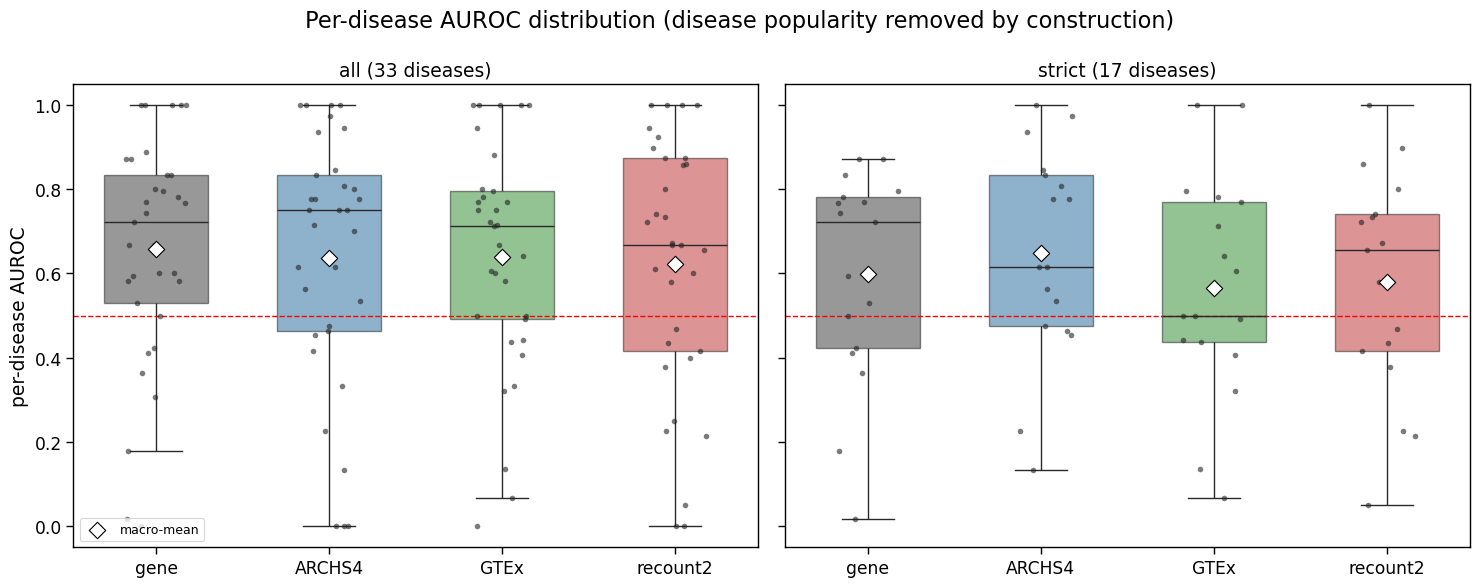

In [10]:
# --- Per-disease AUROC distribution (box + strip), all-33 | strict-17 ---
order = METHOD_ORDER
palette = [METHOD_COLOR[m] for m in order]
labels = [METHOD_LABEL[m] for m in order]

with sns.plotting_context('paper', font_scale=1.4):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    for ax, elig in zip(axes, ['all', 'strict']):
        sub = per_disease[per_disease[ELIGIBILITY[elig]]]
        sns.boxplot(data=sub, x='method', y='auroc', order=order, ax=ax,
                    palette=palette, showfliers=False, width=0.6, boxprops=dict(alpha=0.55))
        sns.stripplot(data=sub, x='method', y='auroc', order=order, ax=ax,
                      color='#222222', size=4, jitter=0.18, alpha=0.6)
        # macro-mean marker (equal-weight) as a white diamond.
        macro = sub.groupby('method', observed=True)['auroc'].mean().reindex(order)
        ax.scatter(range(len(order)), macro.values, marker='D', s=70,
                   color='white', edgecolor='black', zorder=10, label='macro-mean')
        ax.axhline(0.5, color='red', linestyle='--', linewidth=1)
        n_dis = sub['trait'].nunique()
        ax.set_title(f'{elig} ({n_dis} diseases)')
        ax.set_xlabel('')
        ax.set_xticklabels(labels)
        ax.set_ylabel('per-disease AUROC')
    axes[0].legend(loc='lower left', fontsize=9)
    fig.suptitle('Per-disease AUROC distribution (disease popularity removed by construction)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'per_disease_auroc_dist.png', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()

/tmp/claude-1000/ipykernel_848187/2942226717.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='method', y='auprc_log2_enrich', order=order, ax=ax,
/tmp/claude-1000/ipykernel_848187/2942226717.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/claude-1000/ipykernel_848187/2942226717.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='method', y='auprc_log2_enrich', order=order, ax=ax,
/tmp/claude-1000/ipykernel_848187/2942226717.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a

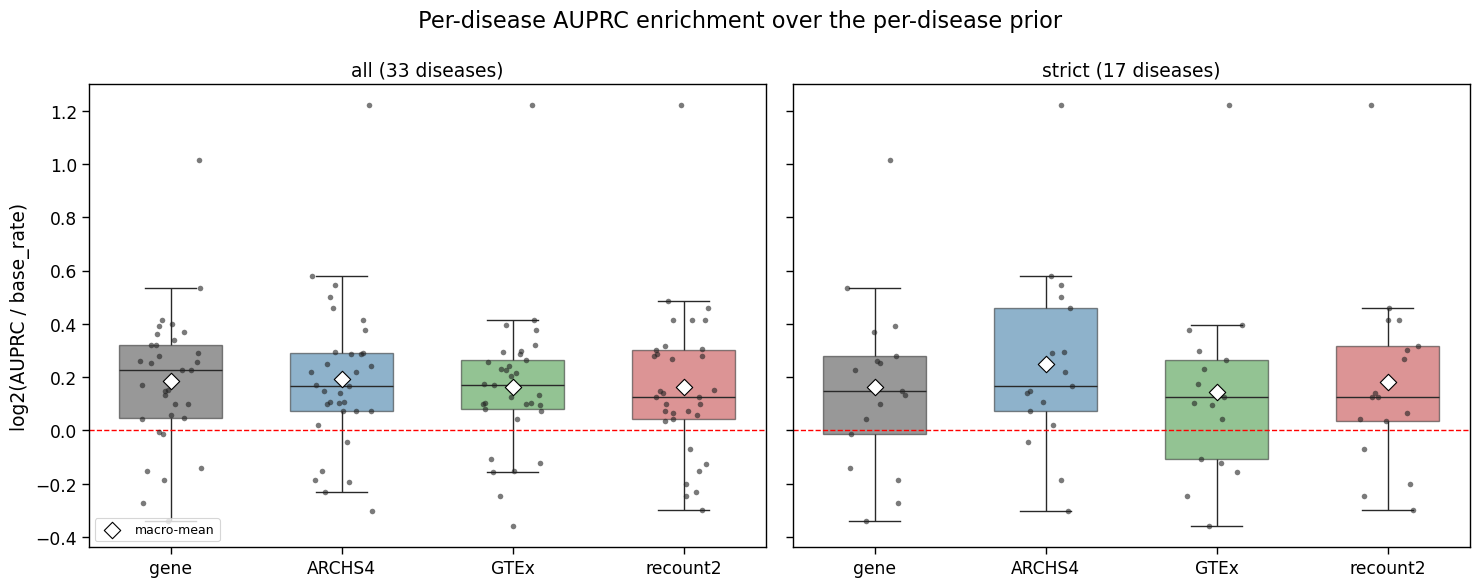

In [11]:
# --- Per-disease log2 AUPRC enrichment distribution (0 = no better than prior) ---
with sns.plotting_context('paper', font_scale=1.4):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    for ax, elig in zip(axes, ['all', 'strict']):
        sub = per_disease[per_disease[ELIGIBILITY[elig]]]
        sns.boxplot(data=sub, x='method', y='auprc_log2_enrich', order=order, ax=ax,
                    palette=palette, showfliers=False, width=0.6, boxprops=dict(alpha=0.55))
        sns.stripplot(data=sub, x='method', y='auprc_log2_enrich', order=order, ax=ax,
                      color='#222222', size=4, jitter=0.18, alpha=0.6)
        macro = sub.groupby('method', observed=True)['auprc_log2_enrich'].mean().reindex(order)
        ax.scatter(range(len(order)), macro.values, marker='D', s=70,
                   color='white', edgecolor='black', zorder=10, label='macro-mean')
        ax.axhline(0.0, color='red', linestyle='--', linewidth=1)
        n_dis = sub['trait'].nunique()
        ax.set_title(f'{elig} ({n_dis} diseases)')
        ax.set_xlabel('')
        ax.set_xticklabels(labels)
        ax.set_ylabel('log2(AUPRC / base_rate)')
    axes[0].legend(loc='lower left', fontsize=9)
    fig.suptitle('Per-disease AUPRC enrichment over the per-disease prior')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'per_disease_auprc_enrich_dist.png', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()

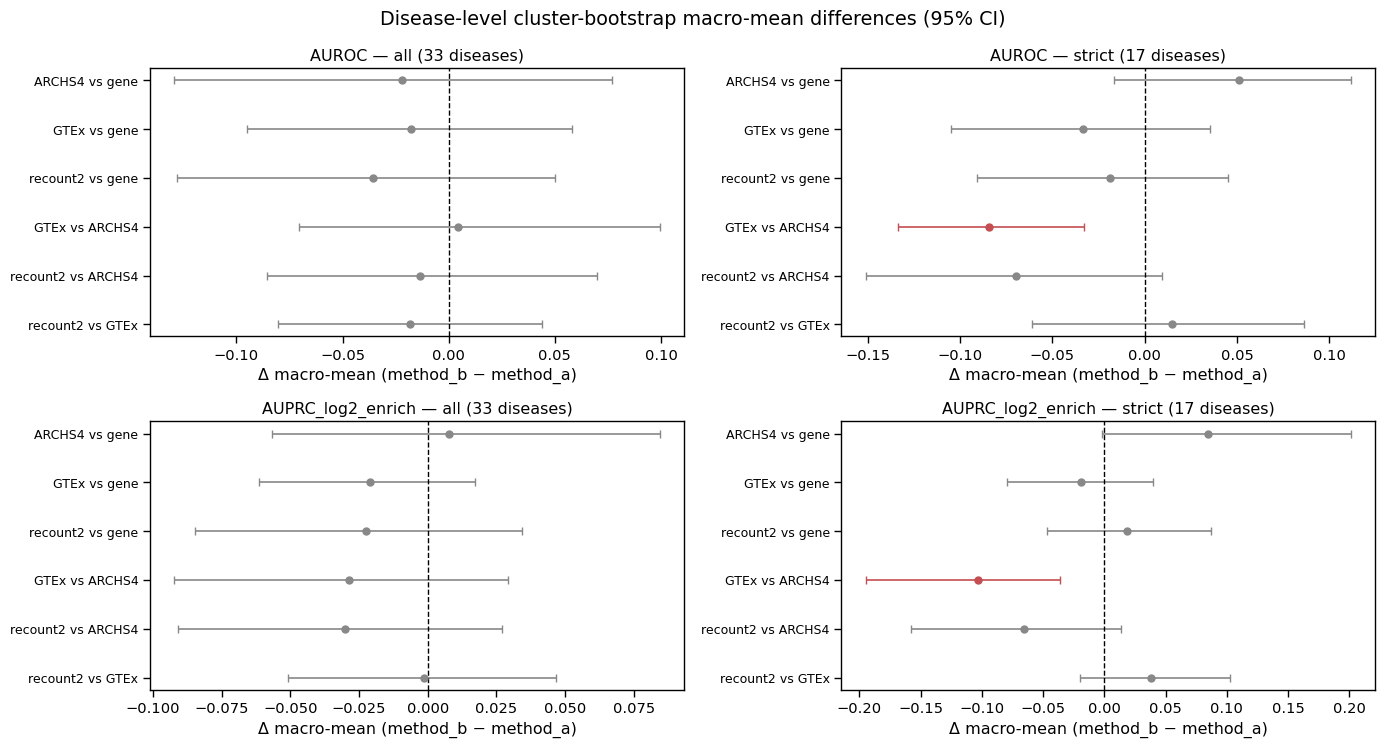

In [12]:
# --- Forest plot of macro-mean differences: rows=metric, cols=eligibility ---
elig_list = list(ELIGIBILITY)
metric_list = list(METRICS)
with sns.plotting_context('paper', font_scale=1.2):
    fig, axes = plt.subplots(
        len(metric_list), len(elig_list),
        figsize=(7 * len(elig_list), 0.6 * len(COMPARISONS) + 2 * len(metric_list)),
        squeeze=False)
    for i, mname in enumerate(metric_list):
        for j, elig in enumerate(elig_list):
            ax = axes[i][j]
            sub = results[(results['metric'] == mname) & (results['eligibility'] == elig)]
            sub = sub.reset_index(drop=True)
            ypos = np.arange(len(sub))[::-1]
            for y, (_, r) in zip(ypos, sub.iterrows()):
                color = '#C44E52' if r['ci_excludes_0'] else '#888888'
                ax.errorbar(
                    r['diff_obs'], y,
                    xerr=[[r['diff_obs'] - r['diff_ci_lo']],
                          [r['diff_ci_hi'] - r['diff_obs']]],
                    fmt='o', color=color, ecolor=color, capsize=3, markersize=5)
            ax.axvline(0, color='black', linestyle='--', linewidth=1)
            ax.set_yticks(ypos)
            ax.set_yticklabels(
                [f"{METHOD_LABEL[r['method_b']]} vs {METHOD_LABEL[r['method_a']]}"
                 for _, r in sub.iterrows()], fontsize=9)
            n_dis = int(summary.loc[summary['eligibility'] == elig, 'n_diseases'].iloc[0])
            ax.set_title(f'{mname} — {elig} ({n_dis} diseases)')
            ax.set_xlabel(f'Δ macro-mean (method_b − method_a)')
    fig.suptitle('Disease-level cluster-bootstrap macro-mean differences (95% CI)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'per_disease_macro_diff_forest.png', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()

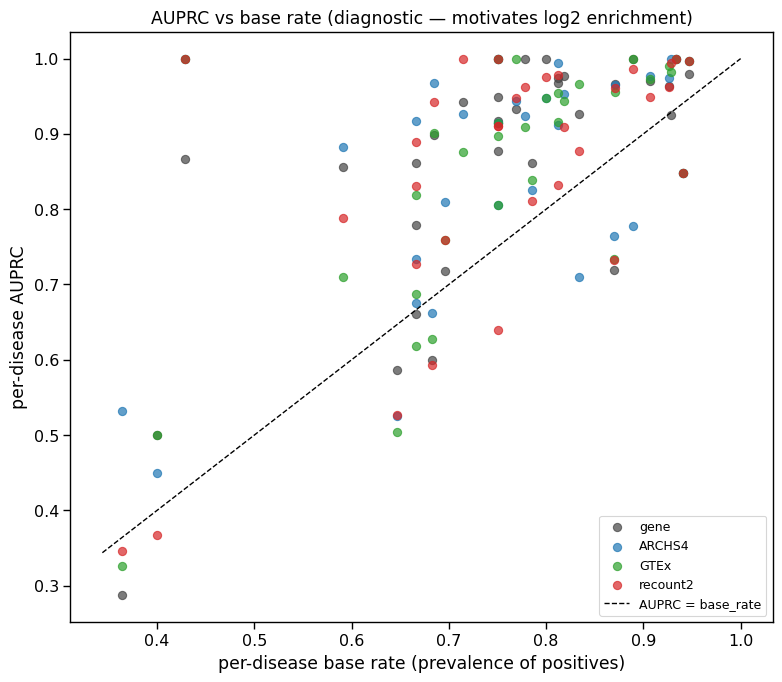

In [13]:
# --- Diagnostic: per-disease AUPRC vs base_rate ---
# AUROC is base-rate-invariant in expectation, but AUPRC tracks the prior; this
# motivates the log2-enrichment normalization. The diagonal is the no-skill line
# (AUPRC = base_rate); points above it are better-than-prior precision.
with sns.plotting_context('paper', font_scale=1.3):
    fig, ax = plt.subplots(figsize=(8, 7))
    sub = per_disease[per_disease['eligible']]
    for m in METHOD_ORDER:
        d = sub[sub['method'] == m]
        ax.scatter(d['base_rate'], d['auprc'], s=35, alpha=0.7,
                   color=METHOD_COLOR[m], label=METHOD_LABEL[m])
    lims = [sub['base_rate'].min() - 0.02, 1.0]
    ax.plot(lims, lims, color='black', linestyle='--', linewidth=1, label='AUPRC = base_rate')
    ax.set_xlabel('per-disease base rate (prevalence of positives)')
    ax.set_ylabel('per-disease AUPRC')
    ax.set_title('AUPRC vs base rate (diagnostic — motivates log2 enrichment)')
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'per_disease_auprc_vs_baserate.png', dpi=150, bbox_inches='tight',
                facecolor='white')
    plt.show()

# Write FINDINGS.md

In [14]:
def _fmt_macro(elig, metric_col):
    s = (per_disease[per_disease[ELIGIBILITY[elig]]]
         .groupby('method', observed=True)[metric_col].mean().reindex(METHOD_ORDER))
    return ', '.join(f'{METHOD_LABEL[m]}={s[m]:.4f}' for m in METHOD_ORDER)


def _fmt_diff_rows(metric, elig):
    sub = results[(results['metric'] == metric) & (results['eligibility'] == elig)]
    lines = []
    for _, r in sub.iterrows():
        sig = 'SIGNIFICANT' if r['ci_excludes_0'] else 'n.s.'
        lines.append(
            f"- {METHOD_LABEL[r['method_b']]} vs {METHOD_LABEL[r['method_a']]}: "
            f"diff={r['diff_obs']:+.4f} [{r['diff_ci_lo']:+.4f}, {r['diff_ci_hi']:+.4f}], "
            f"p={r['p_value']:.3f} (BH {r['p_value_bh']:.3f}) -> {sig}")
    return '\n'.join(lines)


n_total_dis = int(per_disease['trait'].nunique())
one = per_disease[per_disease['method'] == METHOD_ORDER[0]]
n_all_pos = int(((one['n_neg'] == 0) & (one['n_pos'] > 0)).sum())
n_all_neg = int(((one['n_pos'] == 0) & (one['n_neg'] > 0)).sum())
br_lo, br_hi = one.loc[one['eligible'], 'base_rate'].min(), one.loc[one['eligible'], 'base_rate'].max()
nt_lo, nt_hi = one.loc[one['eligible'], 'n_total'].min(), one.loc[one['eligible'], 'n_total'].max()

frac = lambda elig, m: float(
    (per_disease[(per_disease[ELIGIBILITY[elig]]) & (per_disease['method'] == m)]['auroc'] > 0.5).mean())

# Data-driven significance summary (BH-corrected within each metric × eligibility family).
sig = results[results['p_value_bh'] < 0.05]
if len(sig) == 0:
    sig_summary = 'No pairwise difference is BH-significant on either disease set (all CIs cross 0).'
else:
    parts = [
        f"{METHOD_LABEL[r['method_b']]} vs {METHOD_LABEL[r['method_a']]} "
        f"({r['metric']}, {r['eligibility']}: diff={r['diff_obs']:+.3f}, BH p={r['p_value_bh']:.3f})"
        for _, r in sig.iterrows()]
    sig_summary = 'BH-significant pairwise differences: ' + '; '.join(parts) + '.'

text = f'''# Findings — per-disease AUROC + AUPRC

Scope: per-disease metrics within each disease's candidate drugs, 685-pair PharmacotherapyDB
universe (4 methods, from `../signif_test/predictions_paired.pkl`). Disease-level cluster
bootstrap N={N_BOOT} (seed {SEED}), resampling **diseases** (the independent unit once the
disease node is fixed). Macro-mean weights diseases **equally**. AUPRC headline =
`log2(AUPRC / base_rate)` (fold-enrichment over the per-disease prior; 0 = no better than prior).

Of {n_total_dis} diseases in the universe, **{n_all}** are AUROC-eligible (>=1 pos & >=1 neg) and
**{n_strict}** are strict (>=3 & >=3). {n_total_dis - n_all} are AUROC-undefined
({n_all_pos} all-positive, {n_all_neg} all-negative). Eligible-disease base rates span
{br_lo:.2f}-{br_hi:.2f}; per-disease n_total spans {nt_lo}-{nt_hi}.

## Macro-mean per-disease AUROC by method
- all ({n_all} diseases):    {_fmt_macro('all', 'auroc')}
- strict ({n_strict} diseases): {_fmt_macro('strict', 'auroc')}
- frac AUROC>0.5, ARCHS4: all={frac('all','module_based_archs4'):.2f}, strict={frac('strict','module_based_archs4'):.2f}
- frac AUROC>0.5, gene:   all={frac('all','gene_based'):.2f}, strict={frac('strict','gene_based'):.2f}

## Macro-mean log2 AUPRC enrichment by method
- all ({n_all} diseases):    {_fmt_macro('all', 'auprc_log2_enrich')}
- strict ({n_strict} diseases): {_fmt_macro('strict', 'auprc_log2_enrich')}

## Pairwise macro-mean AUROC differences (cluster bootstrap, diff = b - a)
### all ({n_all} diseases)
{_fmt_diff_rows('AUROC', 'all')}
### strict ({n_strict} diseases)
{_fmt_diff_rows('AUROC', 'strict')}

## Pairwise macro-mean log2-AUPRC-enrichment differences
### all ({n_all} diseases)
{_fmt_diff_rows('AUPRC_log2_enrich', 'all')}
### strict ({n_strict} diseases)
{_fmt_diff_rows('AUPRC_log2_enrich', 'strict')}

## Read
- **The macro-mean ordering is threshold-sensitive.** On the well-powered strict-{n_strict}
  diseases ARCHS4 leads (matches the NEXT_STEPS preliminary: ARCHS4 ~0.649, gene ~0.598,
  ARCHS4 >0.5 in ~71%). On the full {n_all}-disease set the gene baseline is comparable / slightly
  higher — the thinly-sampled diseases (1 pos or 1 neg) add noise that erases ARCHS4's edge.
- **Significance:** {sig_summary}
  The ARCHS4-vs-gene baseline comparison is **directional but not significant** on the strict set
  (diff {results[(results.metric=='AUROC')&(results.eligibility=='strict')&(results.method_b=='module_based_archs4')&(results.method_a=='gene_based')]['diff_obs'].iloc[0]:+.3f},
  BH p {results[(results.metric=='AUROC')&(results.eligibility=='strict')&(results.method_b=='module_based_archs4')&(results.method_a=='gene_based')]['p_value_bh'].iloc[0]:.3f})
  and null on the full set — so the headline 'LV beats single-gene' claim remains within noise here,
  consistent with `../signif_test`. The robust signal is an **intra-LV** difference (ARCHS4 > GTEx
  among well-powered diseases), not LV-vs-gene.
- **The contribution is the construction, not the p-value.** Per-disease AUROC removes *disease*
  popularity by construction; the ARCHS4 advantage survives directionally on well-powered diseases.
  Read the significant ARCHS4>GTEx result with the caveats below (correlated methods, n={n_strict}
  clusters, threshold-sensitive — it is absent on the full {n_all}-disease set).

## Caveats
- **Non-random exclusion:** {n_total_dis - n_all}/{n_total_dis} diseases are AUROC-undefined
  (the most label-imbalanced); the per-disease view is conditioned on a non-random disease subset
  (ties to NEXT_STEPS Active #3).
- **Small per-disease n** (median ~14, min 4): individual per-disease AUROCs are near-categorical;
  only distributions / macro-means are interpretable — no per-disease "method X wins in disease Y".
- **n=17-33 disease clusters** is weak power; expect wide CIs. The cluster bootstrap is strictly
  more honest than the pair-level test (correct independence unit), not more powerful.
- Per-disease removes *disease* popularity but not *drug* popularity (NEXT_STEPS notes the residual
  drug-degree rho~0.26 is not considered a relevant concern; no drug-popularity baseline is included).
'''

out_md = OUTPUT_DIR / 'FINDINGS.md'
out_md.write_text(text)
display(out_md)
print(text)

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/per_disease_test/FINDINGS.md')

# Findings — per-disease AUROC + AUPRC

Scope: per-disease metrics within each disease's candidate drugs, 685-pair PharmacotherapyDB
universe (4 methods, from `../signif_test/predictions_paired.pkl`). Disease-level cluster
bootstrap N=10000 (seed 42), resampling **diseases** (the independent unit once the
disease node is fixed). Macro-mean weights diseases **equally**. AUPRC headline =
`log2(AUPRC / base_rate)` (fold-enrichment over the per-disease prior; 0 = no better than prior).

Of 57 diseases in the universe, **33** are AUROC-eligible (>=1 pos & >=1 neg) and
**17** are strict (>=3 & >=3). 24 are AUROC-undefined
(19 all-positive, 5 all-negative). Eligible-disease base rates span
0.36-0.95; per-disease n_total spans 4-85.

## Macro-mean per-disease AUROC by method
- all (33 diseases):    gene=0.6576, ARCHS4=0.6356, GTEx=0.6401, recount2=0.6220
- strict (17 diseases): gene=0.5984, ARCHS4=0.6493, GTEx=0.5652, recount2=0.5798
- frac AUROC>0.5, ARCHS4: all=0.70, strict=0.71
- frac AUROC